### Appendix: cov vs K (not time)

X-axis: K

Y-axis: F(S, Q)

Each curve represents the performance of a method.

In [3]:
import torch
import pickle
import os
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

In [5]:
from plot_utils import crop_pdf_with_fitz, crop_pdf_with_pdfcrop, crop_pdf_with_pypdf,\
    legend_labels, method_label_map, methods, legend_color_map, legend_marker_map

In [6]:
%load_ext autoreload
%autoreload 1

%aimport plot_utils

In [7]:
# Collect data from text files for all datasets
datasets = ['msmarco', 'hotpotqa', 'fever', 'pooled', 'science', 'technology', 'writing']
time_map, max_time_vals = plot_utils.get_time_data(datasets)

msmarco
hotpotqa
fever
pooled
science
technology
writing


In [8]:
max_time_vals

{'msmarco': 1526.22,
 'hotpotqa': 938.81,
 'fever': 974.79,
 'pooled': 572.39,
 'science': 400.16,
 'technology': 264.27,
 'writing': 208.34}

In [9]:
# Load score data
score_map = {ds: {} for ds in datasets}
ind_map = {ds: {} for ds in datasets}

for ds in datasets:
    for method in methods:
        if method == "gold":
            continue
        inds, scores = plot_utils.get_score_data(ds, method, k=10)
        print(f"Shapes for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}")
        assert inds.shape == scores.shape, f"Shape mismatch for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}"
        assert inds.shape[0] > 10
        score_map[ds][method] = scores.mean(dim=0).numpy()
        ind_map[ds][method] = inds

Method is submodlib lazy, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
submodlib lazy + msmarco does not have k=10 data, defaulting to k=15
Shapes for msmarco, submodlib lazy: inds: torch.Size([43, 10]), scores: torch.Size([43, 10])
Method is submodlib stochastic 0.5, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_StochasticGreedy_k10_msmarco_bf_k10_submodlib_no_stop_eps0.5.pkl
Shapes for msmarco, submodlib stochastic 0.5: inds: torch.Size([43, 10]), scores: torch.Size([43, 10])
Method is submodlib ltl 0.1, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazierThanLazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazierThanLazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
submodlib ltl 0.1 + msmarco does not ha

In [15]:
def plot_paper(dataset_name, desired_methods, y_label=True, k_cutoff=4):
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 6))
    markersize = 10

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        'lines.markersize': markersize
    })

    for method in desired_methods:
        iters = range(1, 10 + 1)
        scores = score_map[dataset_name][method].tolist()

        if "bypass" in method:
            scores = scores[:k_cutoff]
            iters = iters[:k_cutoff]

        print(f"Method: {method}, Score: {scores}")
        ax.plot(
            iters,
            scores,
            label=plot_utils.method_label_map[method],
            color=plot_utils.legend_color_map[plot_utils.method_label_map[method]],
            marker=plot_utils.legend_marker_map[plot_utils.method_label_map[method]],
            linewidth=2,
            markersize=14,
        )

    # ax.set_title(f'{dataset_name}: F(S) vs K', fontsize=20)
    # ax.set_xlabel(r'$\textbf{Retrieval time (sec)}$', fontsize=48)      # Increased axis label size
    ax.set_xlabel(r'$\textbf{K}\rightarrow$', fontsize=48)      # Increased axis label size
    if y_label:
        ax.set_ylabel(r'$\textbf{Avg}\quad\pmb{F(S_K, Q)}$', fontsize=48) # Increased axis label size

    # Xticks logscale
    # ax.set_xscale('log')
    # Explicitly set tick label sizes
    ax.tick_params(axis='x', labelsize=50)  # Smaller X-axis tick labels
    ax.tick_params(axis='y', labelsize=50)  # Smaller Y-axis tick labels

    # ax.set_xticks([1, 100, 10000])
    # # Get current x-tick values and format them with LaTeX bold
    # xticks = ax.get_xticks()
    # # Display in 10^i format, and use bold for the numbers
    # powers = [f"10^{int(np.log10(v))}" for v in xticks if v > 0]
    # xticklabels = [fr'$\mathbf{{{p}}}$' for p in powers]
    # ax.set_xticklabels(xticklabels)

    # Get current x-tick values and format them with LaTeX bold
    xticks = ax.get_xticks()
    xticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in xticks]
    ax.set_xticklabels(xticklabels)

    # Get current y-tick values and format them with LaTeX bold
    yticks = ax.get_yticks()
    yticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in yticks]
    ax.set_yticklabels(yticklabels)

    # ax.xaxis.set_label_coords(0.45, -0.2)

    # ax.legend(fontsize=12)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'./notebooks/plots/{dataset_name.lower()}_covK_supp.pdf')
    plt.show()

In [11]:
def plot_legend_only(desired_methods, filename, ncol=3, auto_crop=True):
    # Create a figure for legend only
    fig, ax = plt.subplots(figsize=(8, 6))

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
    })
    
    for method in desired_methods:
        ax.plot(
            [], [],
            label=plot_utils.method_label_map[method],
            color=plot_utils.legend_color_map[plot_utils.method_label_map[method]],
            marker=plot_utils.legend_marker_map[plot_utils.method_label_map[method]],
            linewidth=2,
            markersize=10,
        )

    # Hide the plot area
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Create legend
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        fontsize=25,
        frameon=False
    )

    # Save the figure
    output_path = f'./notebooks/plots/{filename}.pdf'
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()
    
    # Auto-crop the PDF if requested
    if auto_crop:
        # Try methods in order of preference
        cropped_path = crop_pdf_with_pdfcrop(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_fitz(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_pypdf(output_path)
        
        if cropped_path:
            # Replace original with cropped version
            os.rename(cropped_path, output_path)
            print(f"PDF automatically cropped: {output_path}")
        else:
            print("Auto-cropping failed, using matplotlib's bbox_inches='tight' only")

In [12]:
dms = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']

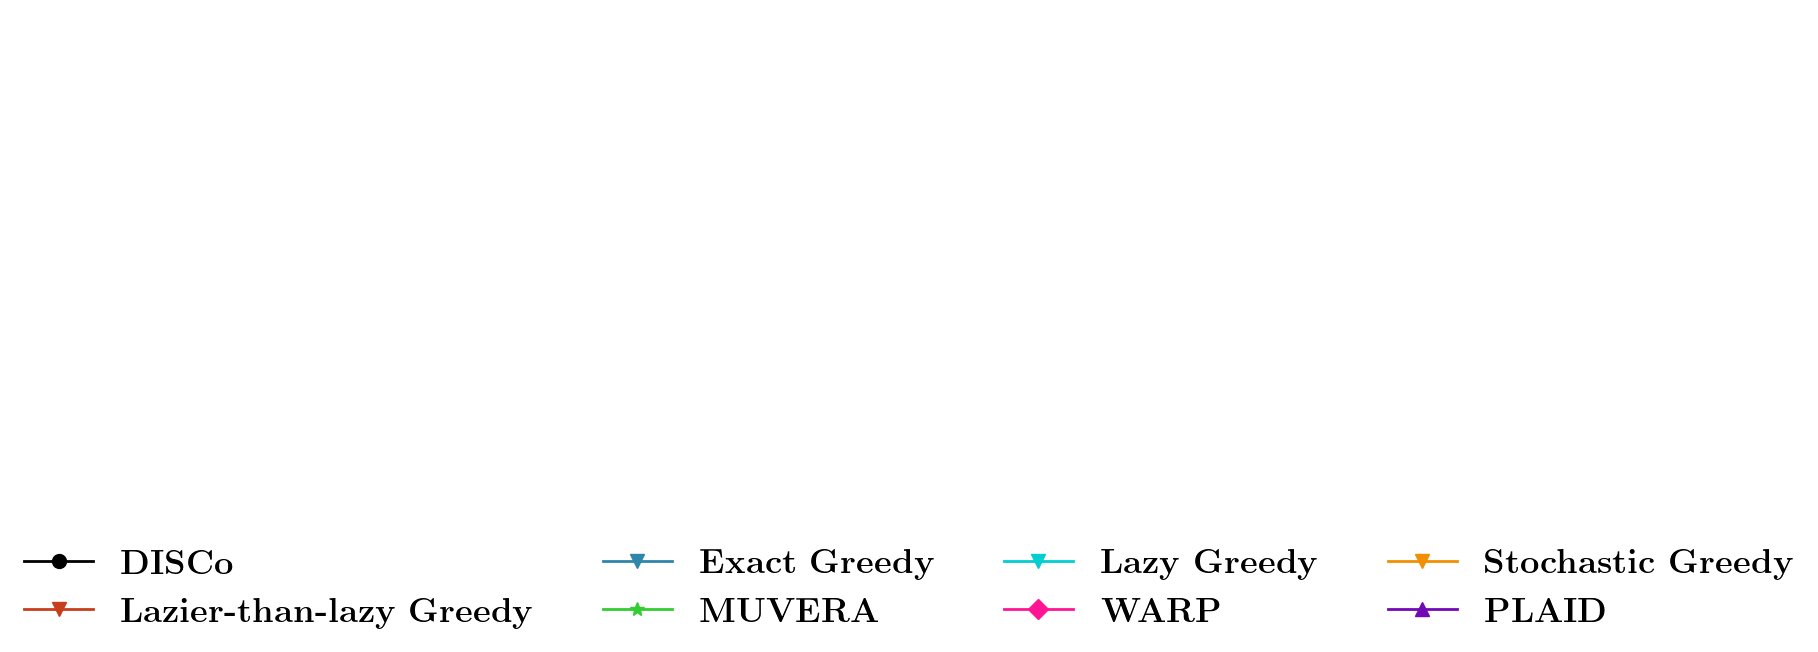

Successfully cropped ./notebooks/plots/covK_supp_legend.pdf -> ./notebooks/plots/covK_supp_legend_cropped.pdf
PDF automatically cropped: ./notebooks/plots/covK_supp_legend.pdf


In [13]:
plot_legend_only(dms, "covK_supp_legend", ncol=4)

Method: ColBERT bypass - 1, Score: [26.90367889404297, 28.02771759033203, 28.134347915649414, 28.14484977722168, 28.146018981933594, 28.14737319946289, 28.15143585205078, 28.15143585205078, 28.15143585205078, 28.15143585205078]
Method: submodlib ltl 0.5, Score: [23.239723205566406, 26.39710807800293, 27.474023818969727, 27.778688430786133, 27.98693084716797, 28.105255126953125, 28.1474552154541, 28.20638656616211, 28.24333381652832, 28.304349899291992]
Method: exact greedy, Score: [26.92869758605957, 28.23822784423828, 28.494949340820312, 28.580991744995117, 28.6215877532959, 28.643089294433594, 28.6568546295166, 28.66512680053711, 28.67012596130371, 28.673187255859375]
Method: MUVERA iid, Score: [25.163864135742188, 25.639963150024414, 26.018779754638672, 26.146705627441406, 26.378040313720703, 26.61919403076172, 26.662050247192383, 26.72208023071289, 26.72917366027832, 26.854398727416992]
Method: submodlib lazy, Score: [26.928699493408203, 28.23822784423828, 28.49494743347168, 28.580

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

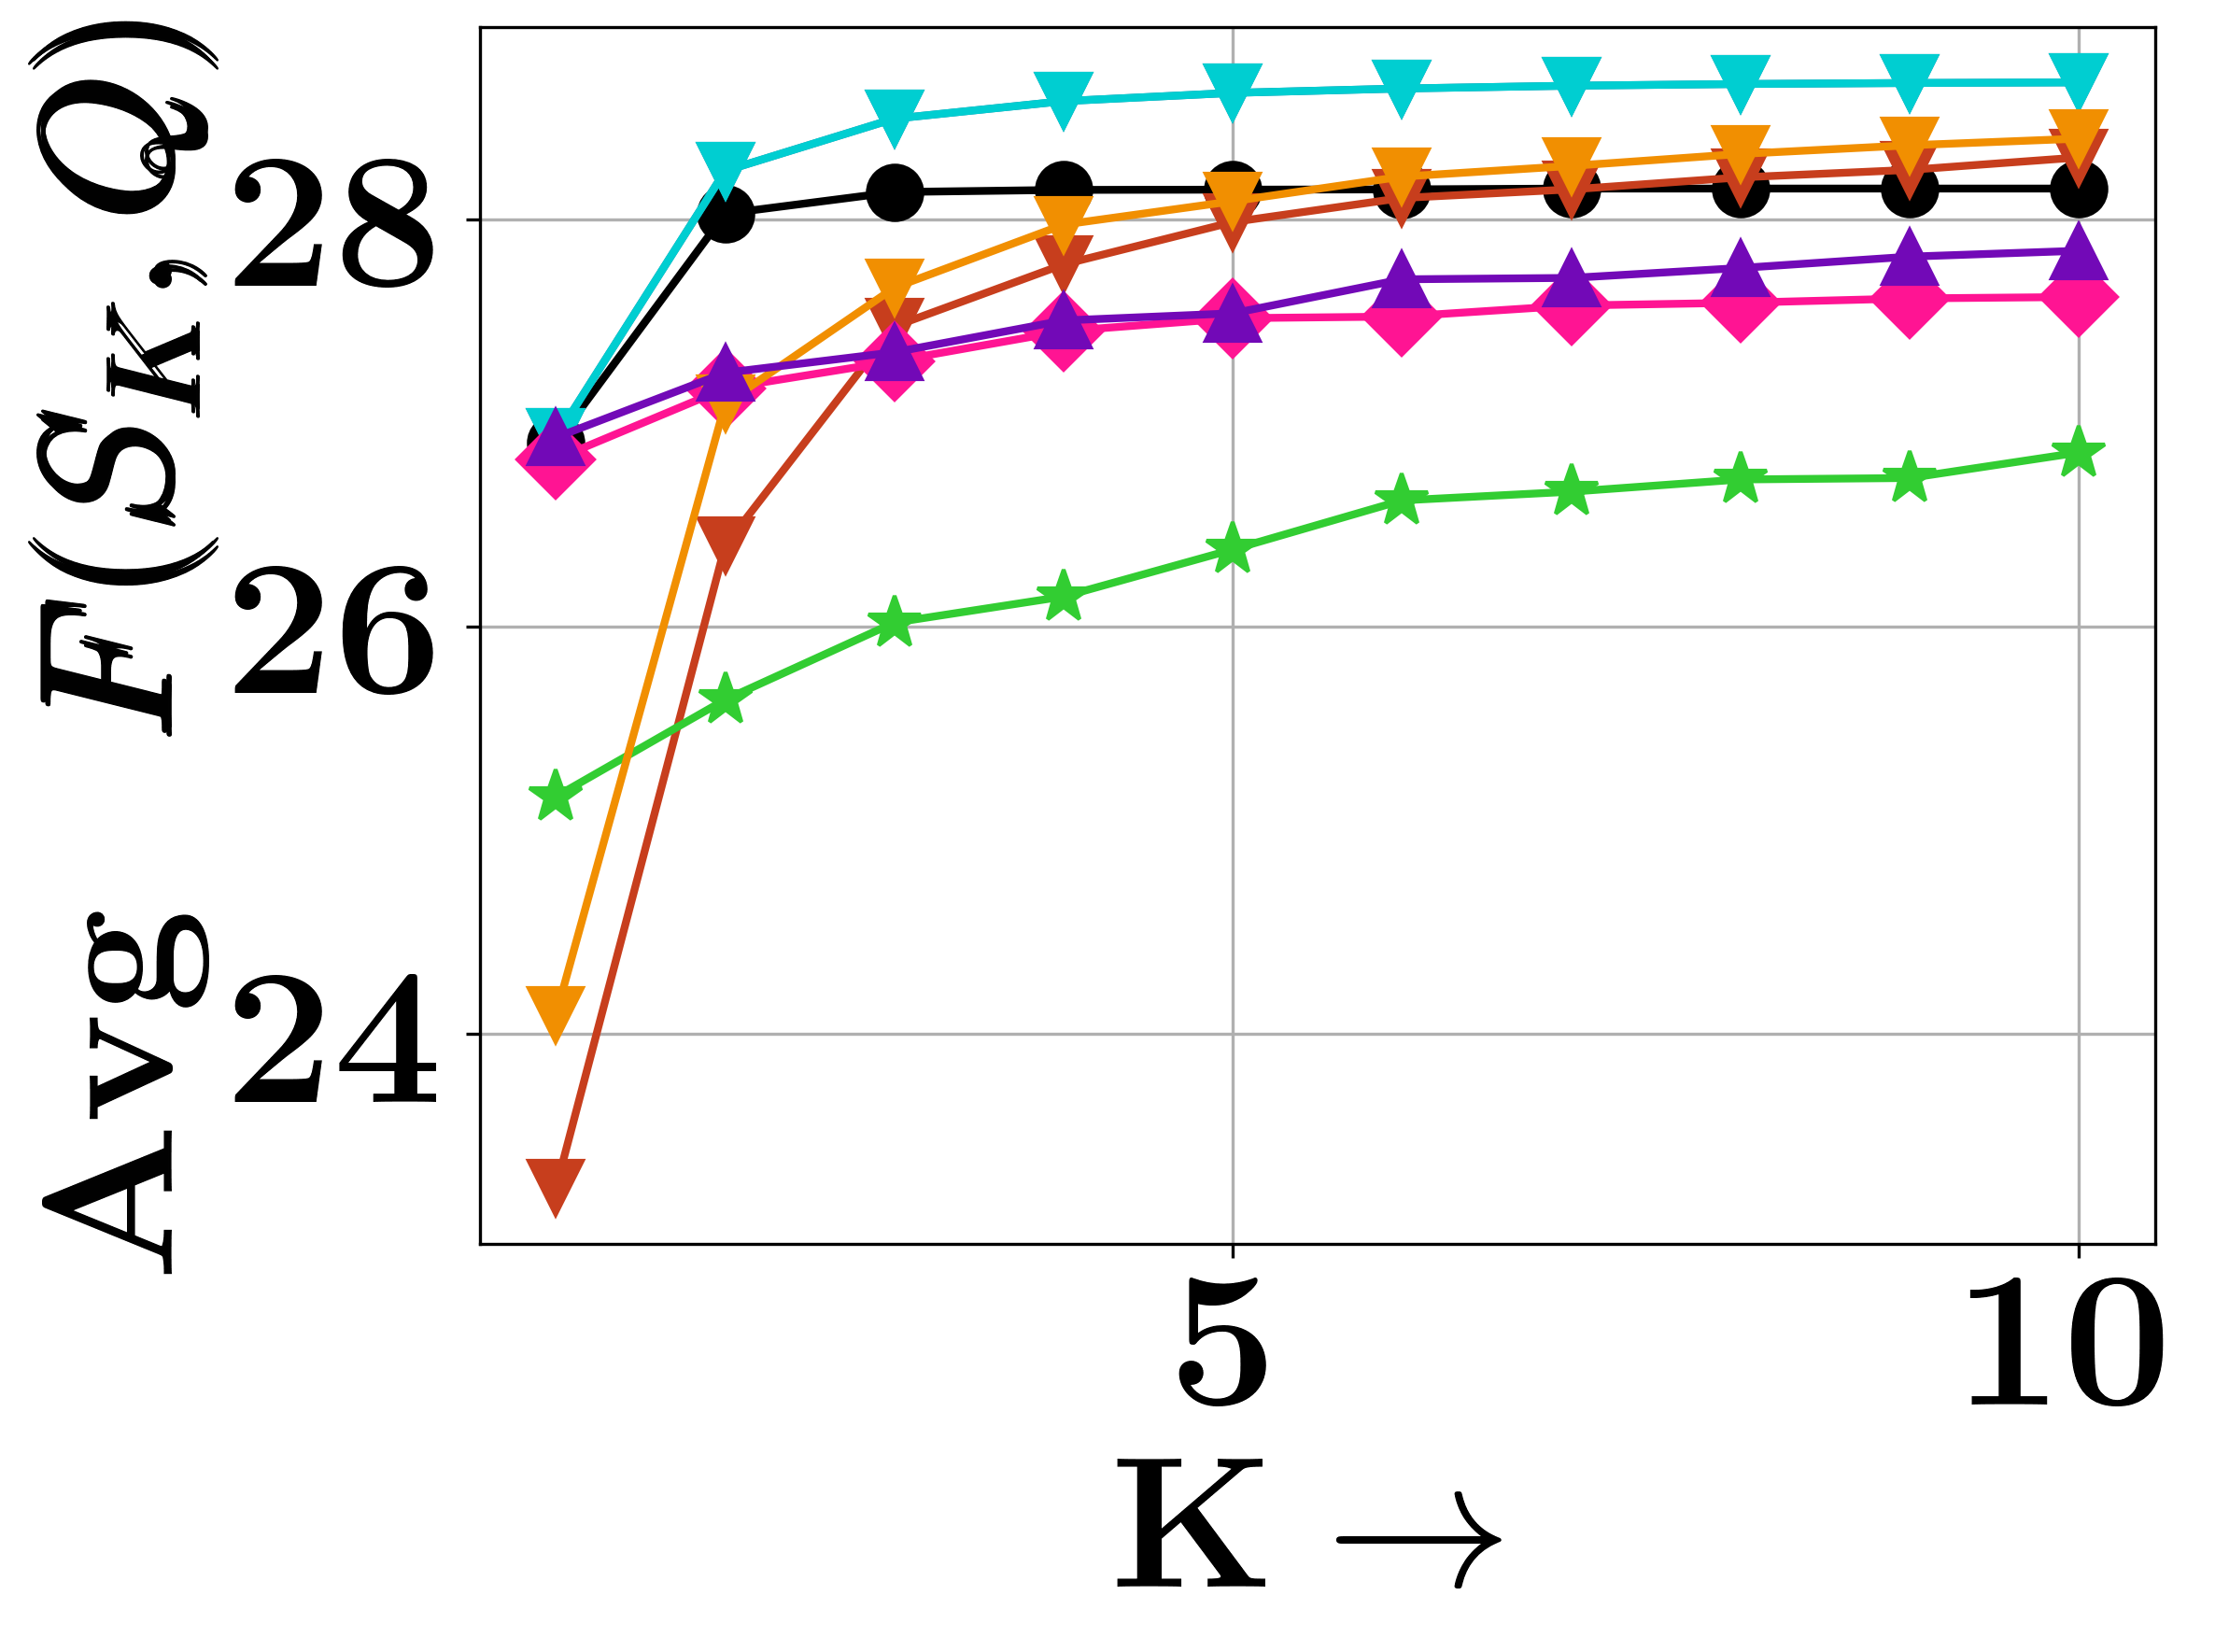

In [16]:
# dms = ['submodlib ltl 0.5', 'exact greedy', 'submodlib lazy', 'submodlib stochastic 0.5']
plot_paper("msmarco", dms, y_label=True, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [23.37869644165039, 25.99539566040039, 26.56996726989746, 26.753440856933594, 26.825660705566406, 26.85806655883789, 26.87279510498047, 26.880081176757812, 26.8836612701416, 26.885421752929688]
Method: submodlib ltl 0.5, Score: [18.77859115600586, 23.118417739868164, 24.771982192993164, 25.555919647216797, 25.97223472595215, 26.243562698364258, 26.422649383544922, 26.55616569519043, 26.647403717041016, 26.72871971130371]
Method: exact greedy, Score: [23.402164459228516, 26.08445930480957, 26.728721618652344, 26.9818058013916, 27.11005401611328, 27.18324851989746, 27.228565216064453, 27.258625030517578, 27.279251098632812, 27.293832778930664]
Method: MUVERA iid, Score: [21.192180633544922, 22.158700942993164, 22.583858489990234, 22.841053009033203, 23.017900466918945, 23.14754295349121, 23.253223419189453, 23.339067459106445, 23.401710510253906, 23.446393966674805]
Method: submodlib lazy, Score: [23.402164459228516, 26.08445930480957, 26.72872161865234

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

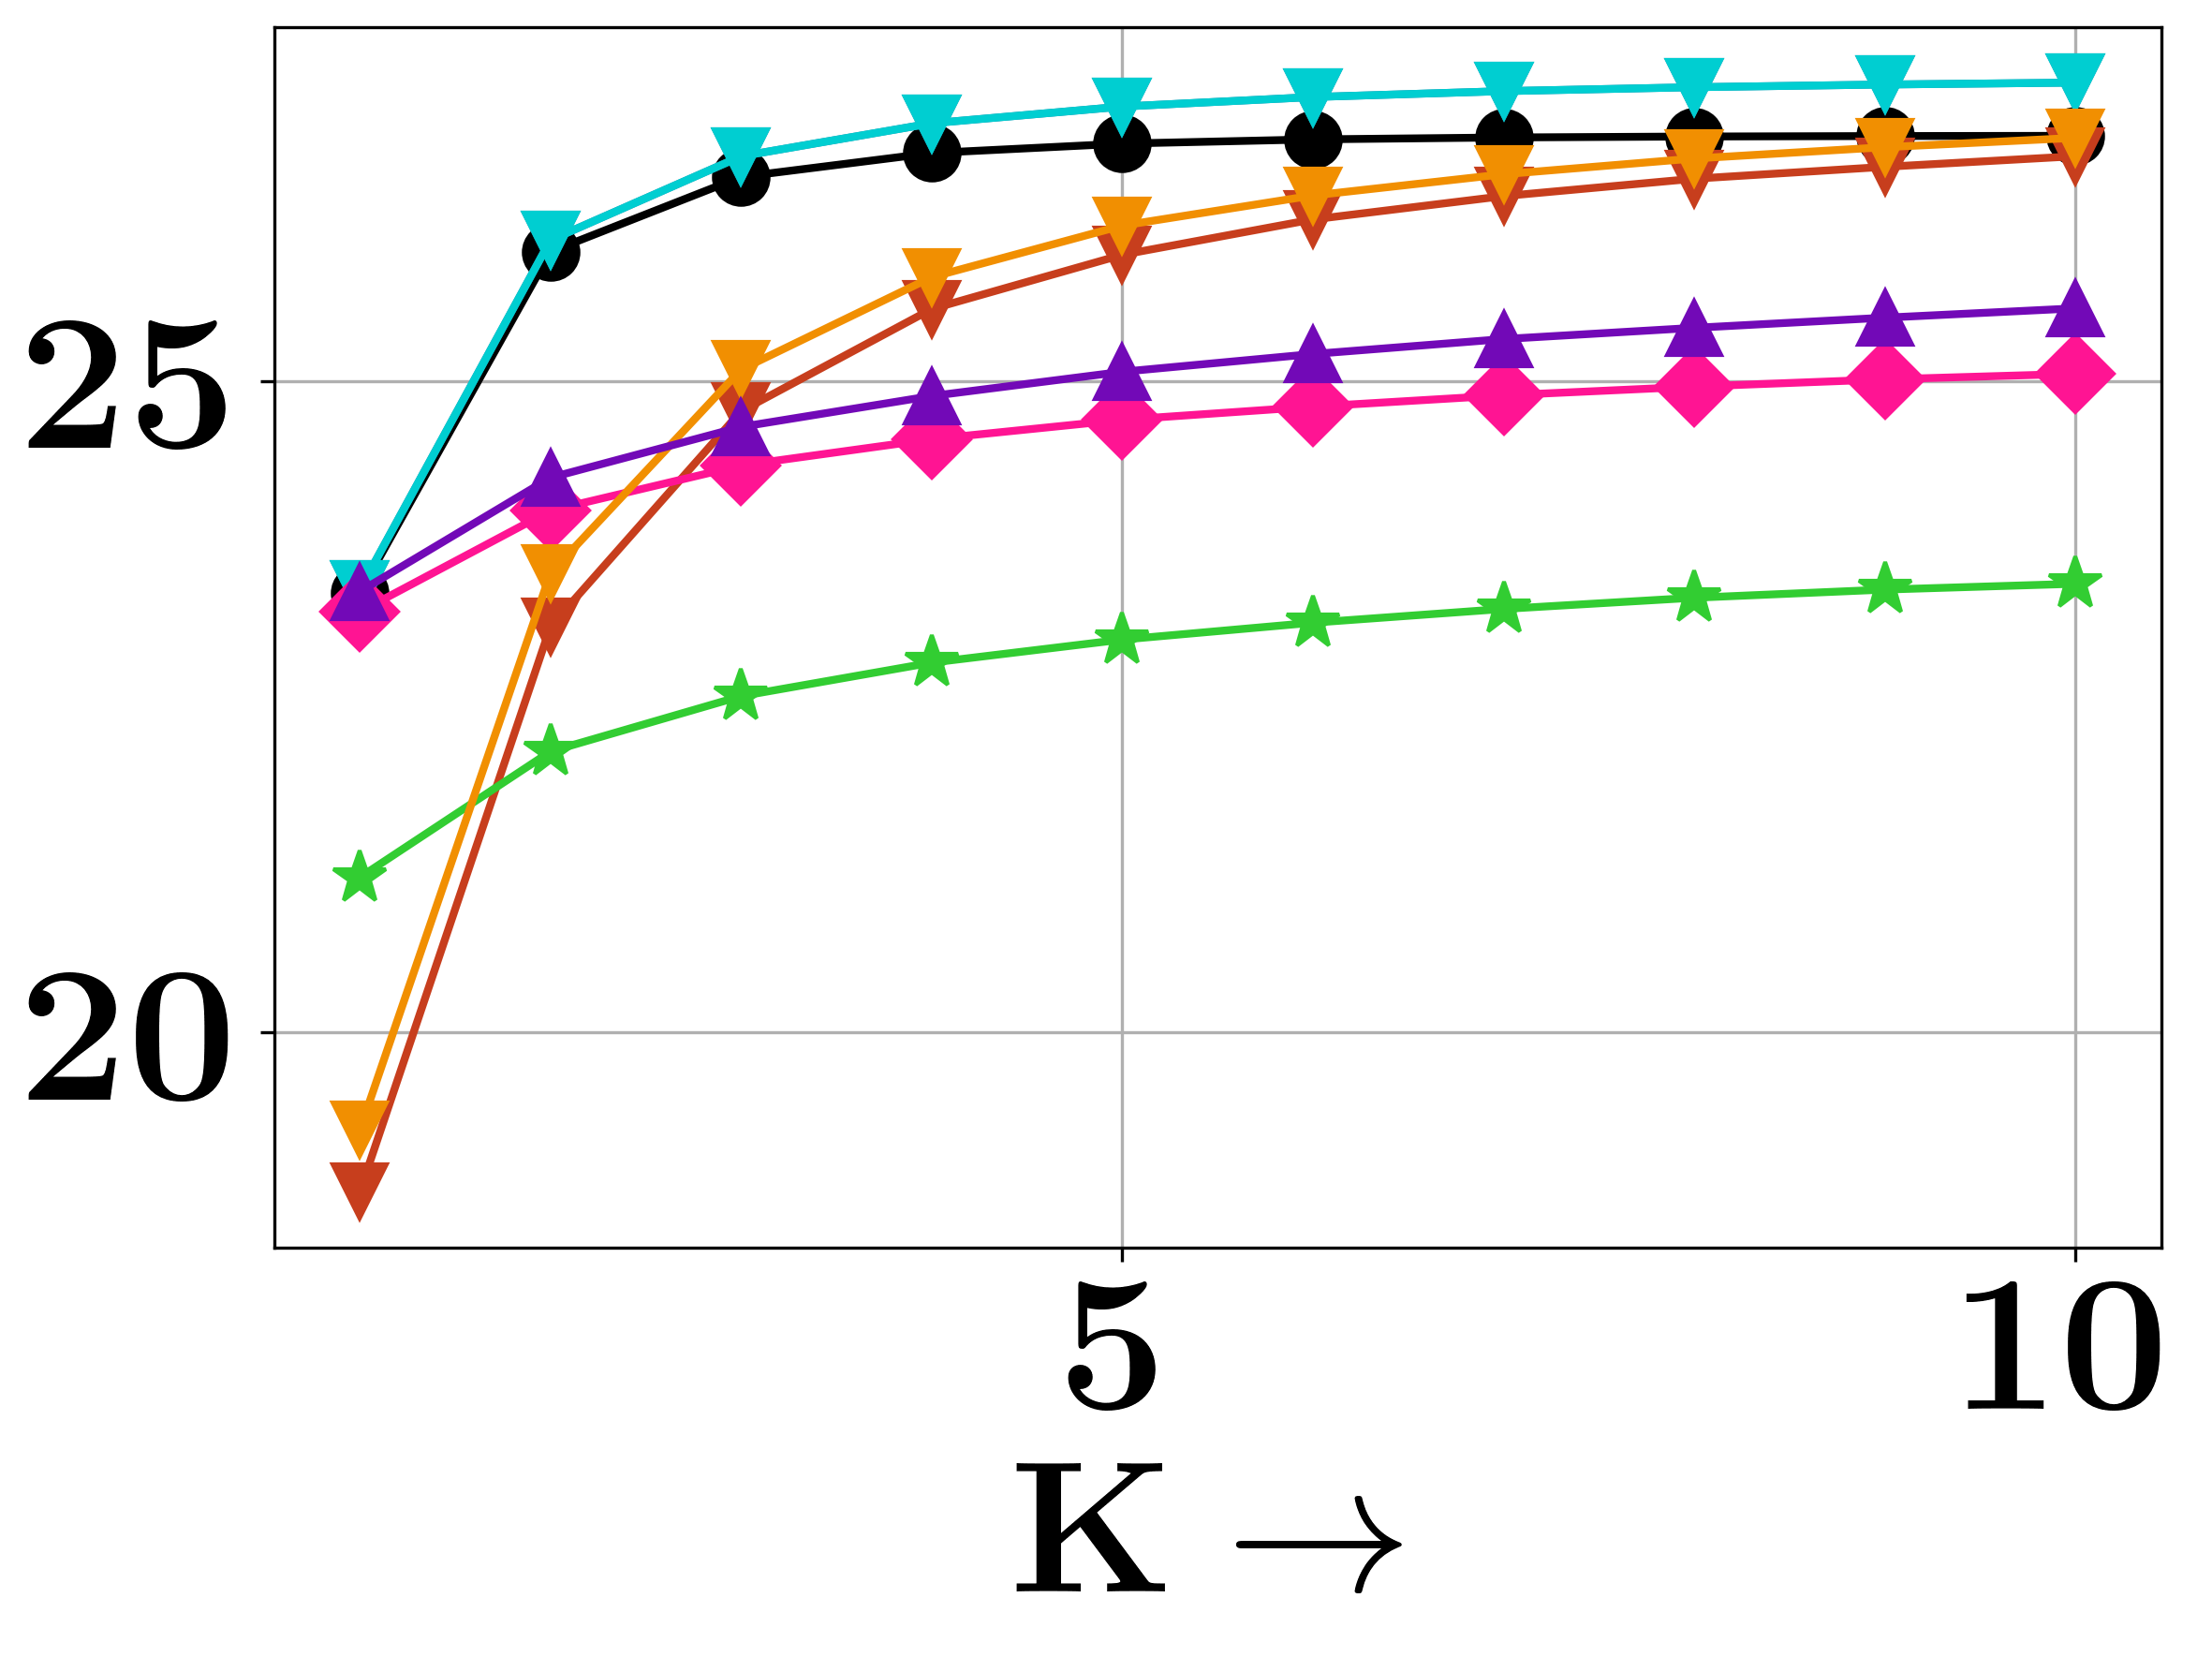

In [17]:
plot_paper("fever", dms, y_label=False, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [20.763174057006836, 24.108600616455078, 24.980749130249023, 25.315217971801758, 25.473495483398438, 25.555395126342773, 25.599281311035156, 25.624122619628906, 25.638429641723633, 25.646442413330078]
Method: submodlib ltl 0.5, Score: [16.761524200439453, 20.62693977355957, 22.55156135559082, 23.597442626953125, 24.22049903869629, 24.61713409423828, 24.892385482788086, 25.096923828125, 25.252309799194336, 25.37165069580078]
Method: exact greedy, Score: [20.77775001525879, 24.150075912475586, 25.073375701904297, 25.46482276916504, 25.685714721679688, 25.824316024780273, 25.918764114379883, 25.98691749572754, 26.03807830810547, 26.077486038208008]
Method: MUVERA iid, Score: [18.806304931640625, 20.090028762817383, 20.590072631835938, 20.88237190246582, 21.066165924072266, 21.205175399780273, 21.308992385864258, 21.392227172851562, 21.452743530273438, 21.504989624023438]
Method: submodlib lazy, Score: [20.77775001525879, 24.150075912475586, 25.0733737945

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

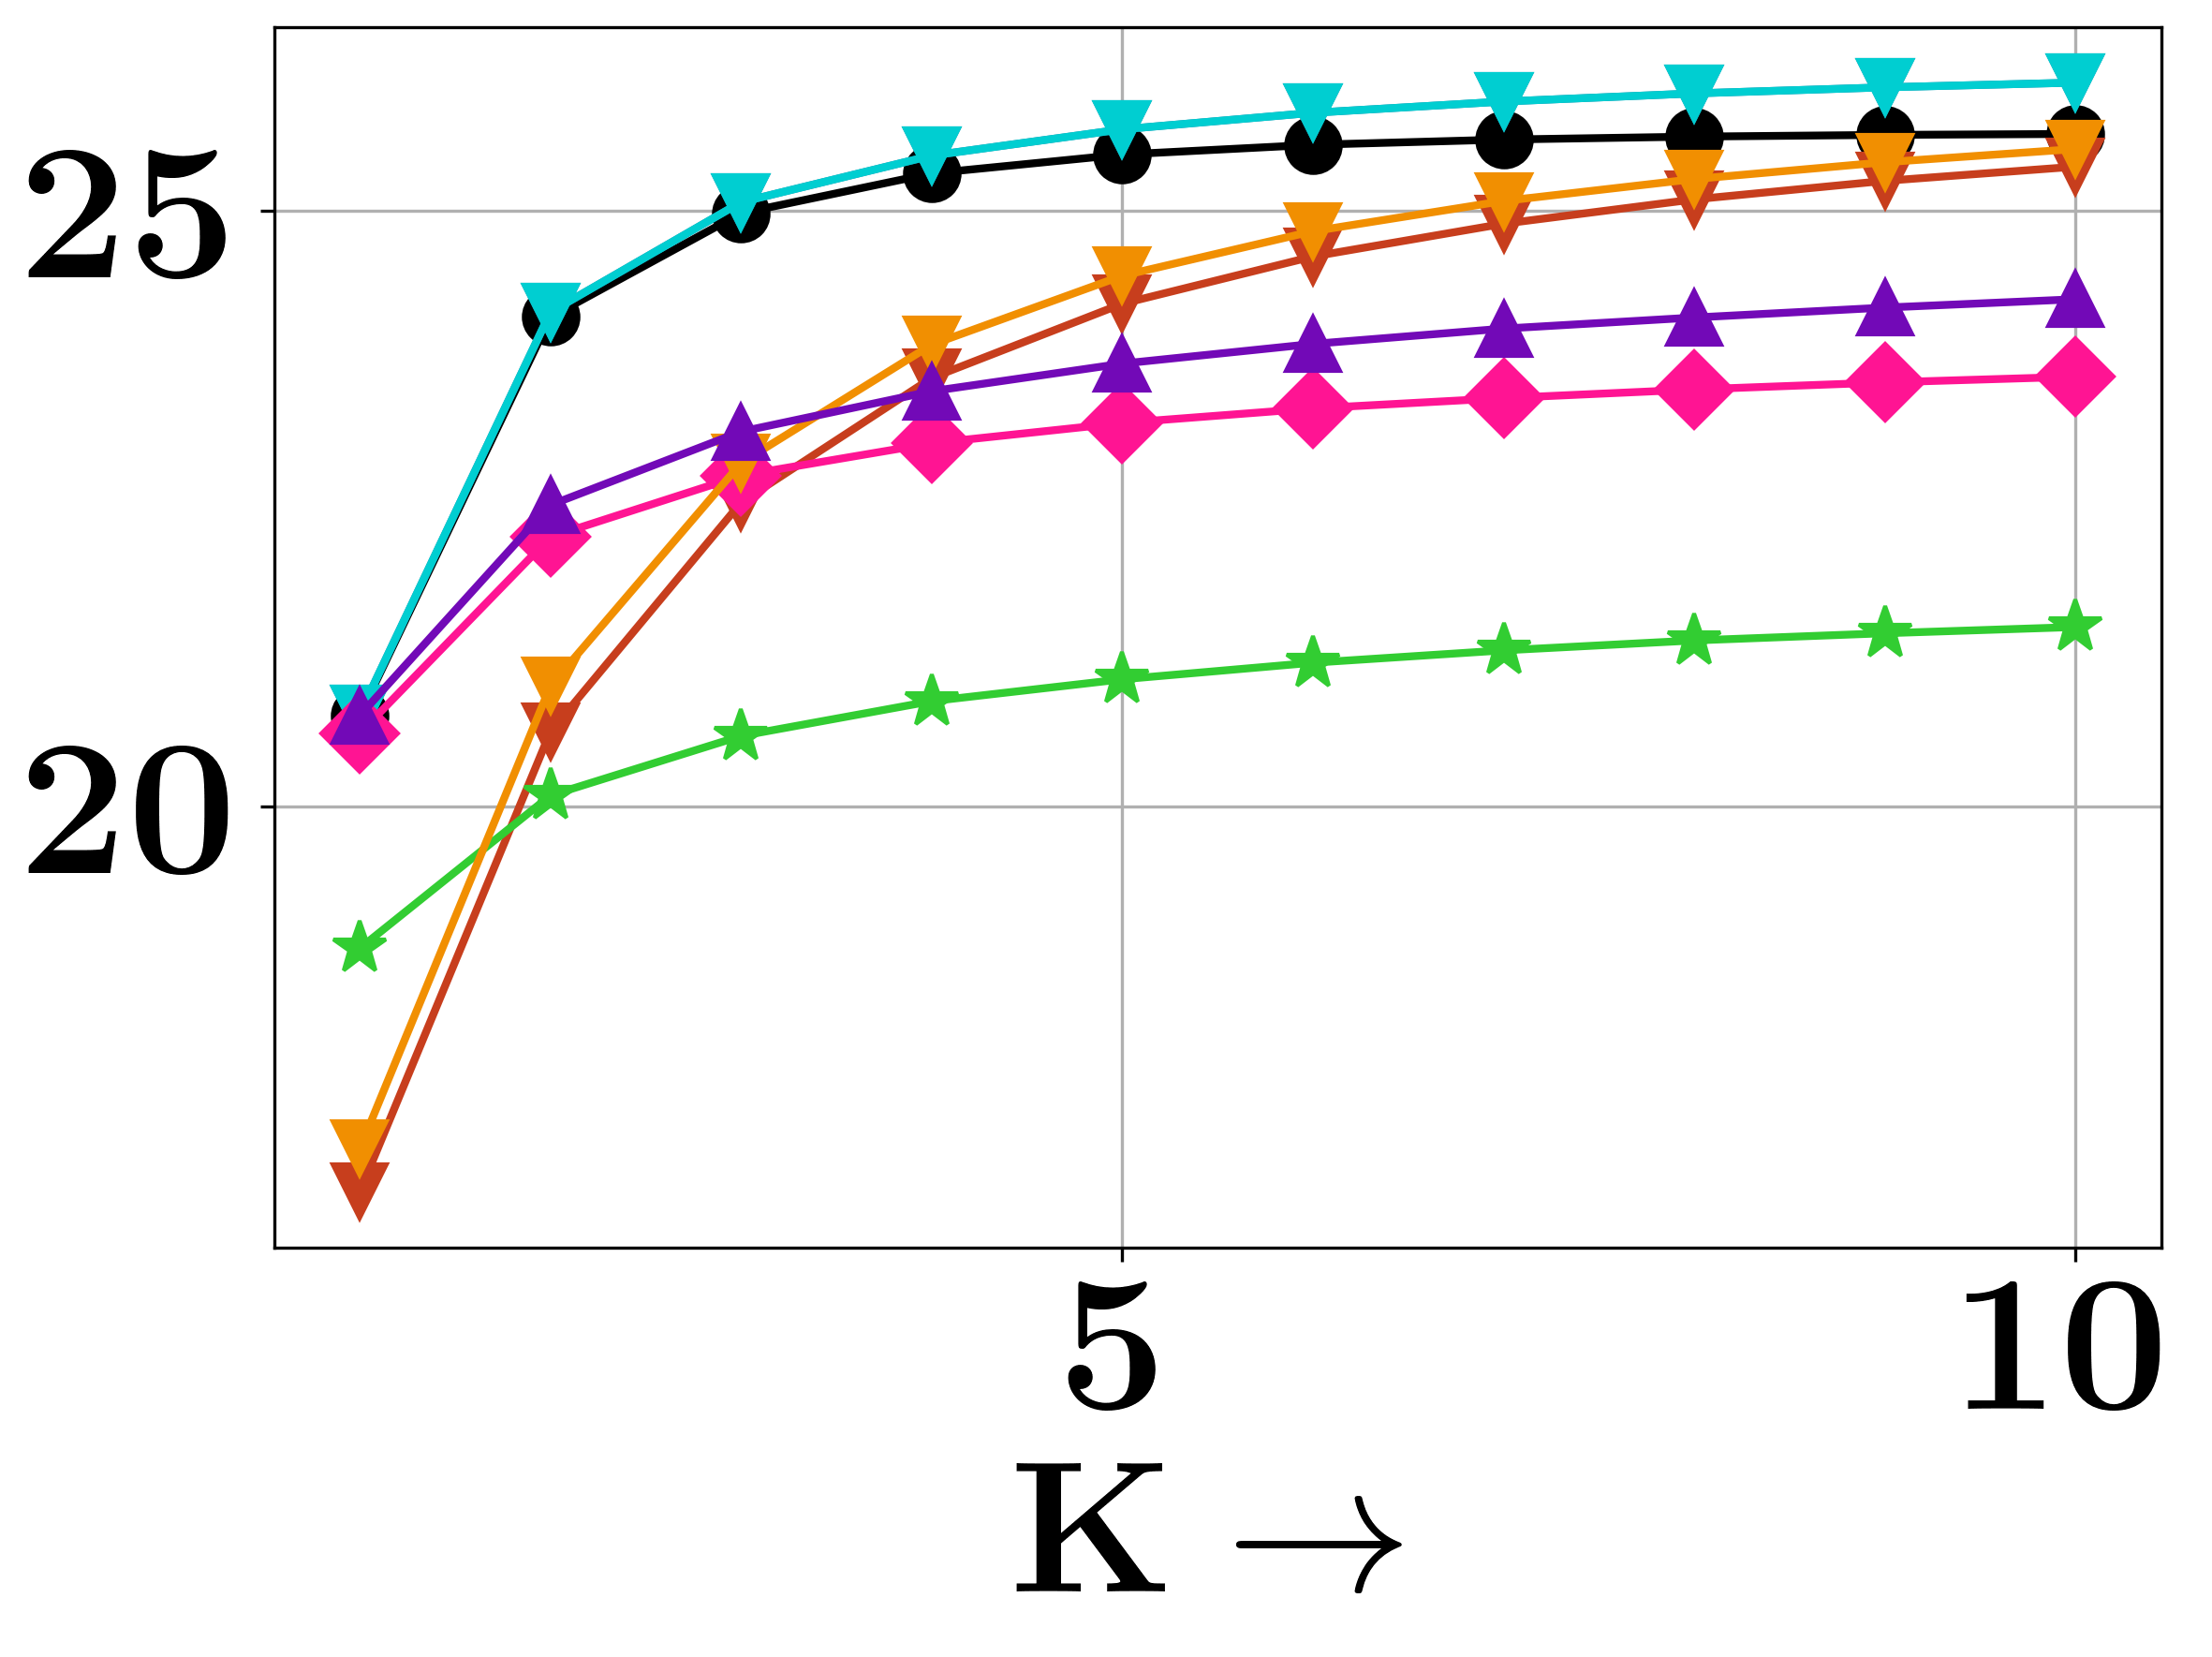

In [18]:
plot_paper("hotpotqa", dms, y_label=False, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [22.179214477539062, 24.403987884521484, 25.078563690185547, 25.35371971130371, 25.482057571411133, 25.54684829711914, 25.582185745239258, 25.60114288330078, 25.61178970336914, 25.617544174194336]
Method: submodlib ltl 0.5, Score: [18.98543930053711, 22.606821060180664, 23.973861694335938, 24.644834518432617, 25.035968780517578, 25.287641525268555, 25.464197158813477, 25.592144012451172, 25.693199157714844, 25.774017333984375]
Method: exact greedy, Score: [22.222328186035156, 24.553874969482422, 25.340688705444336, 25.710542678833008, 25.91344451904297, 26.035846710205078, 26.114322662353516, 26.166994094848633, 26.20359992980957, 26.229698181152344]
Method: MUVERA iid, Score: [19.141923904418945, 20.433927536010742, 21.021453857421875, 21.351715087890625, 21.56709098815918, 21.7158260345459, 21.817886352539062, 21.896629333496094, 21.949634552001953, 21.98836326599121]
Method: submodlib lazy, Score: [22.222328186035156, 24.553874969482422, 25.3406887

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

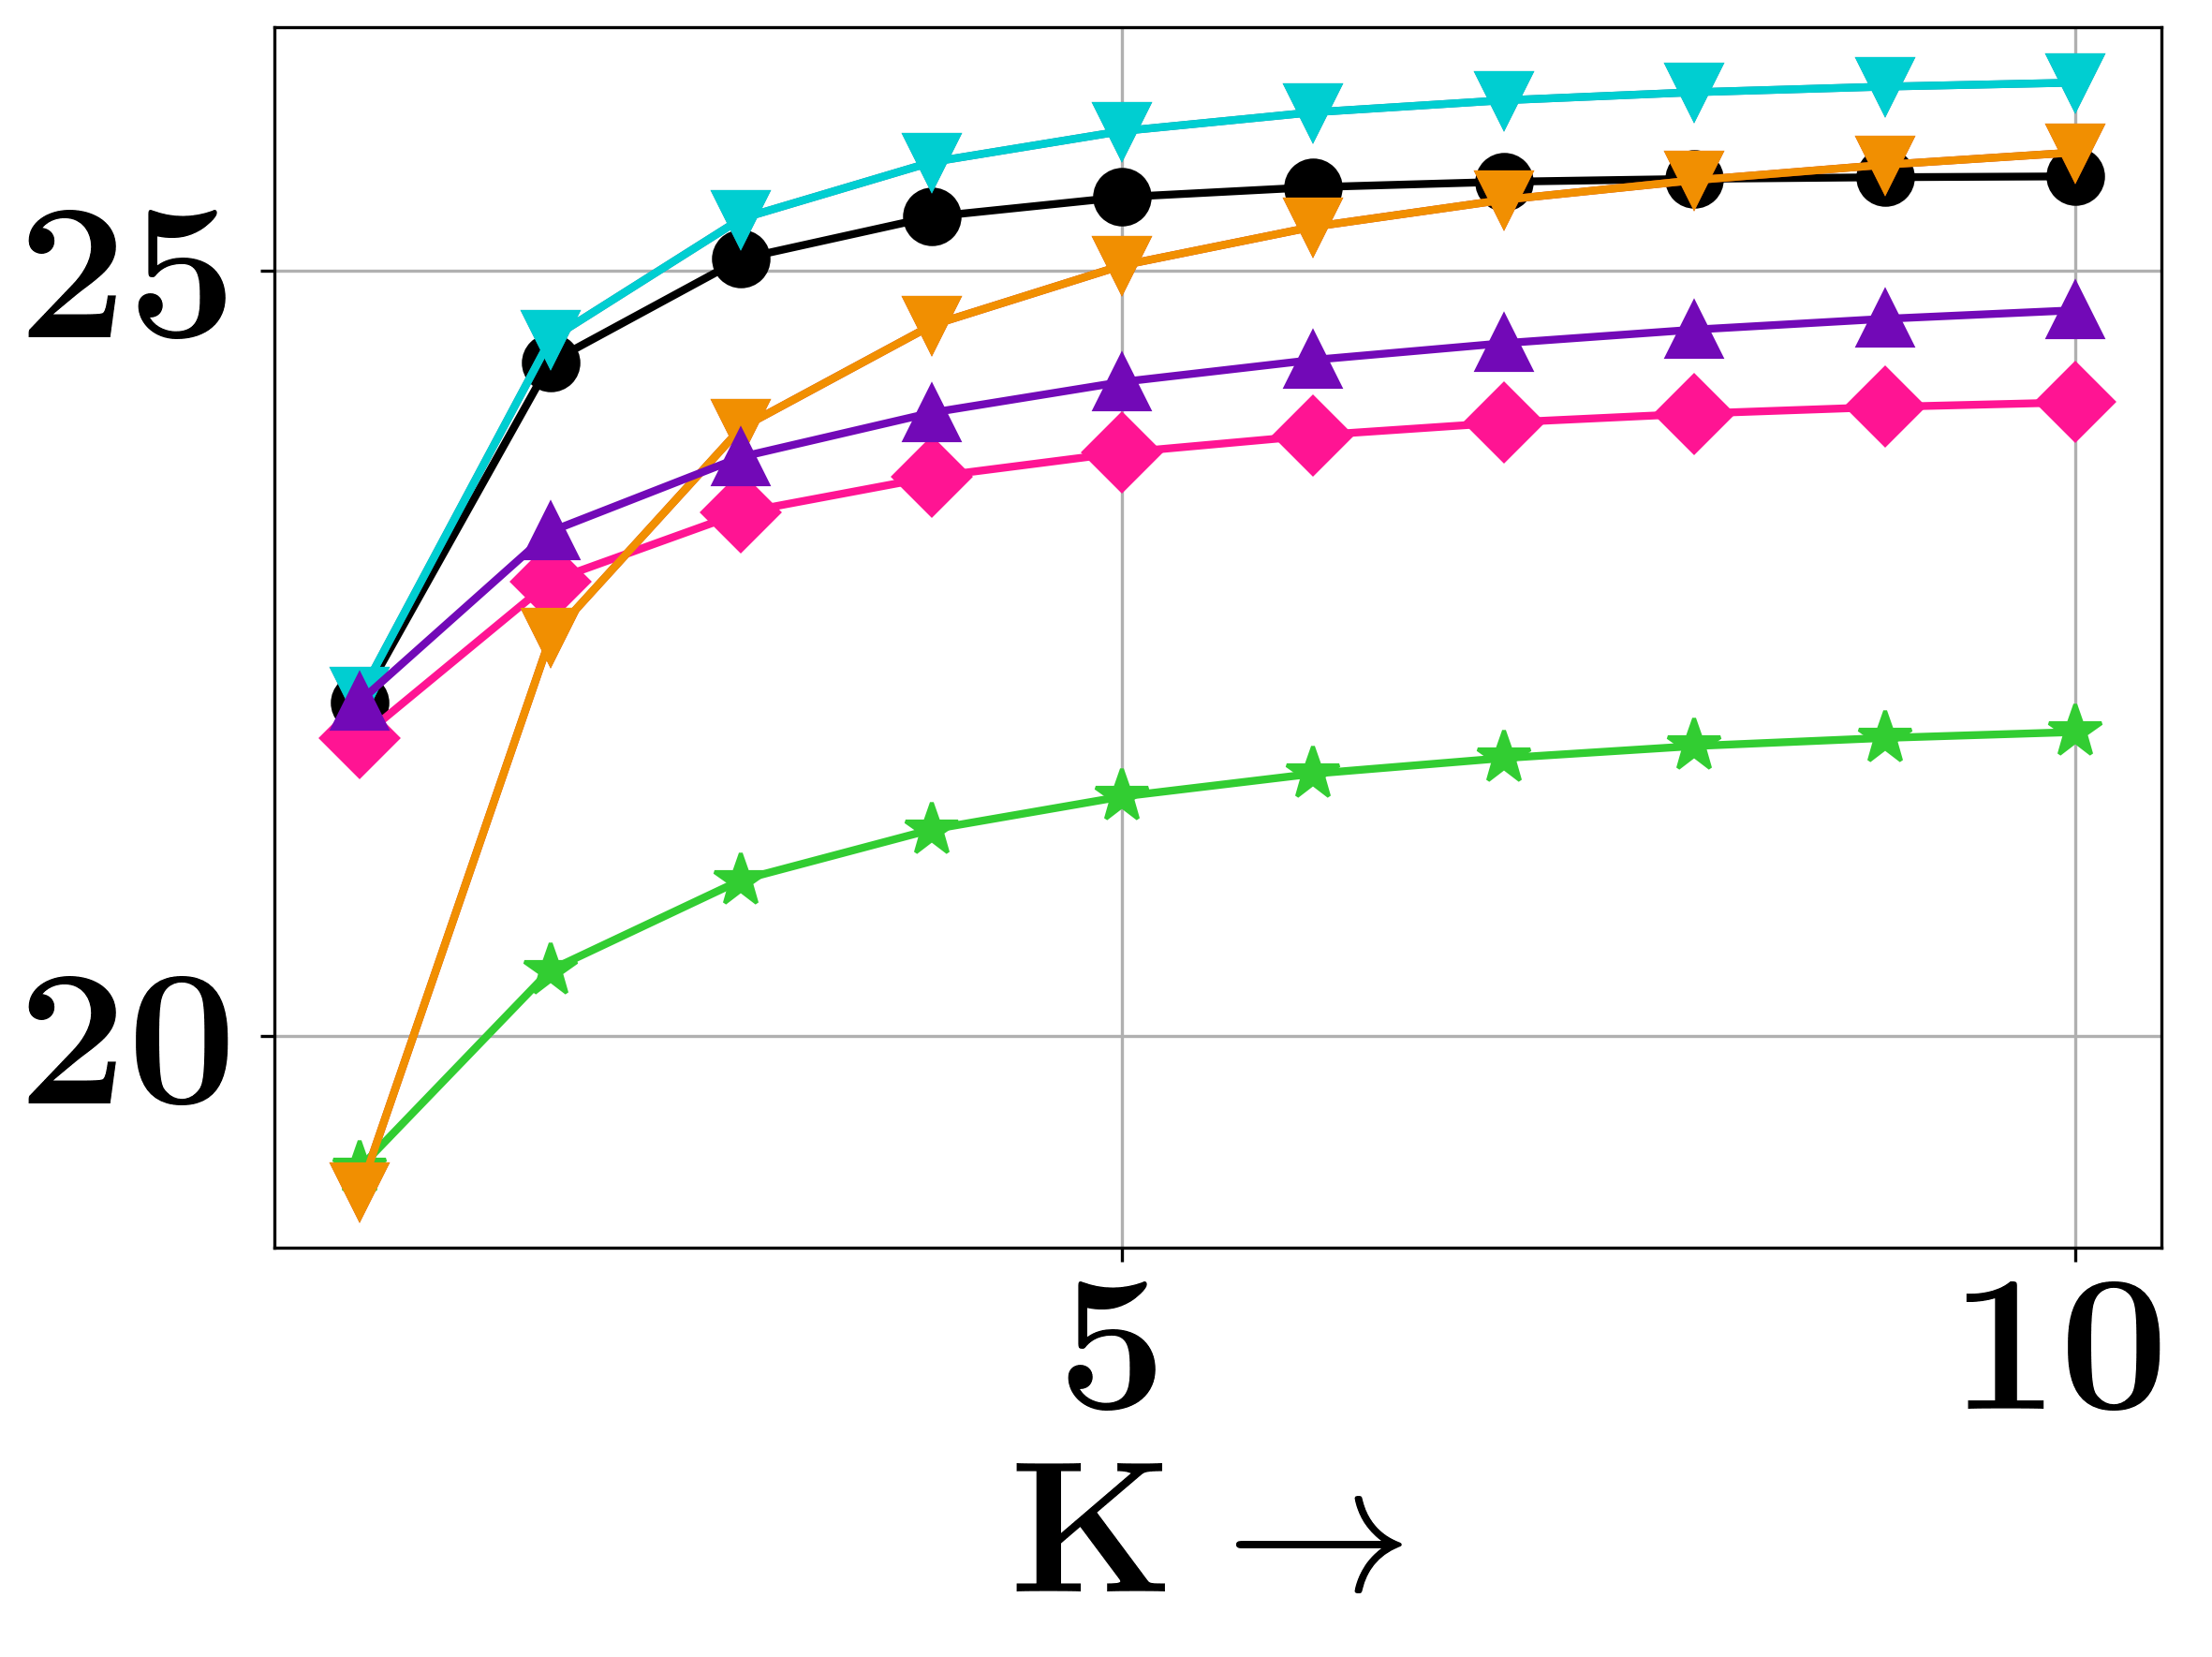

In [19]:
plot_paper("pooled", dms, y_label=False, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [21.884695053100586, 23.849123001098633, 24.44626235961914, 24.68818473815918, 24.80754852294922, 24.871965408325195, 24.905765533447266, 24.924226760864258, 24.93465232849121, 24.94054412841797]
Method: submodlib ltl 0.5, Score: [19.384090423583984, 22.46748924255371, 23.57585906982422, 24.116962432861328, 24.44021224975586, 24.64595603942871, 24.79187774658203, 24.89845848083496, 24.98358917236328, 25.04934310913086]
Method: exact greedy, Score: [21.93305778503418, 23.99359703063965, 24.6750545501709, 24.99469757080078, 25.16806411743164, 25.27025604248047, 25.335426330566406, 25.379371643066406, 25.41006851196289, 25.43199348449707]
Method: MUVERA iid, Score: [18.953569412231445, 20.07395362854004, 20.607154846191406, 20.8906192779541, 21.08280372619629, 21.22604751586914, 21.31749725341797, 21.40045166015625, 21.471914291381836, 21.527963638305664]
Method: submodlib lazy, Score: [21.933055877685547, 23.99359893798828, 24.6750545501709, 24.99469757

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

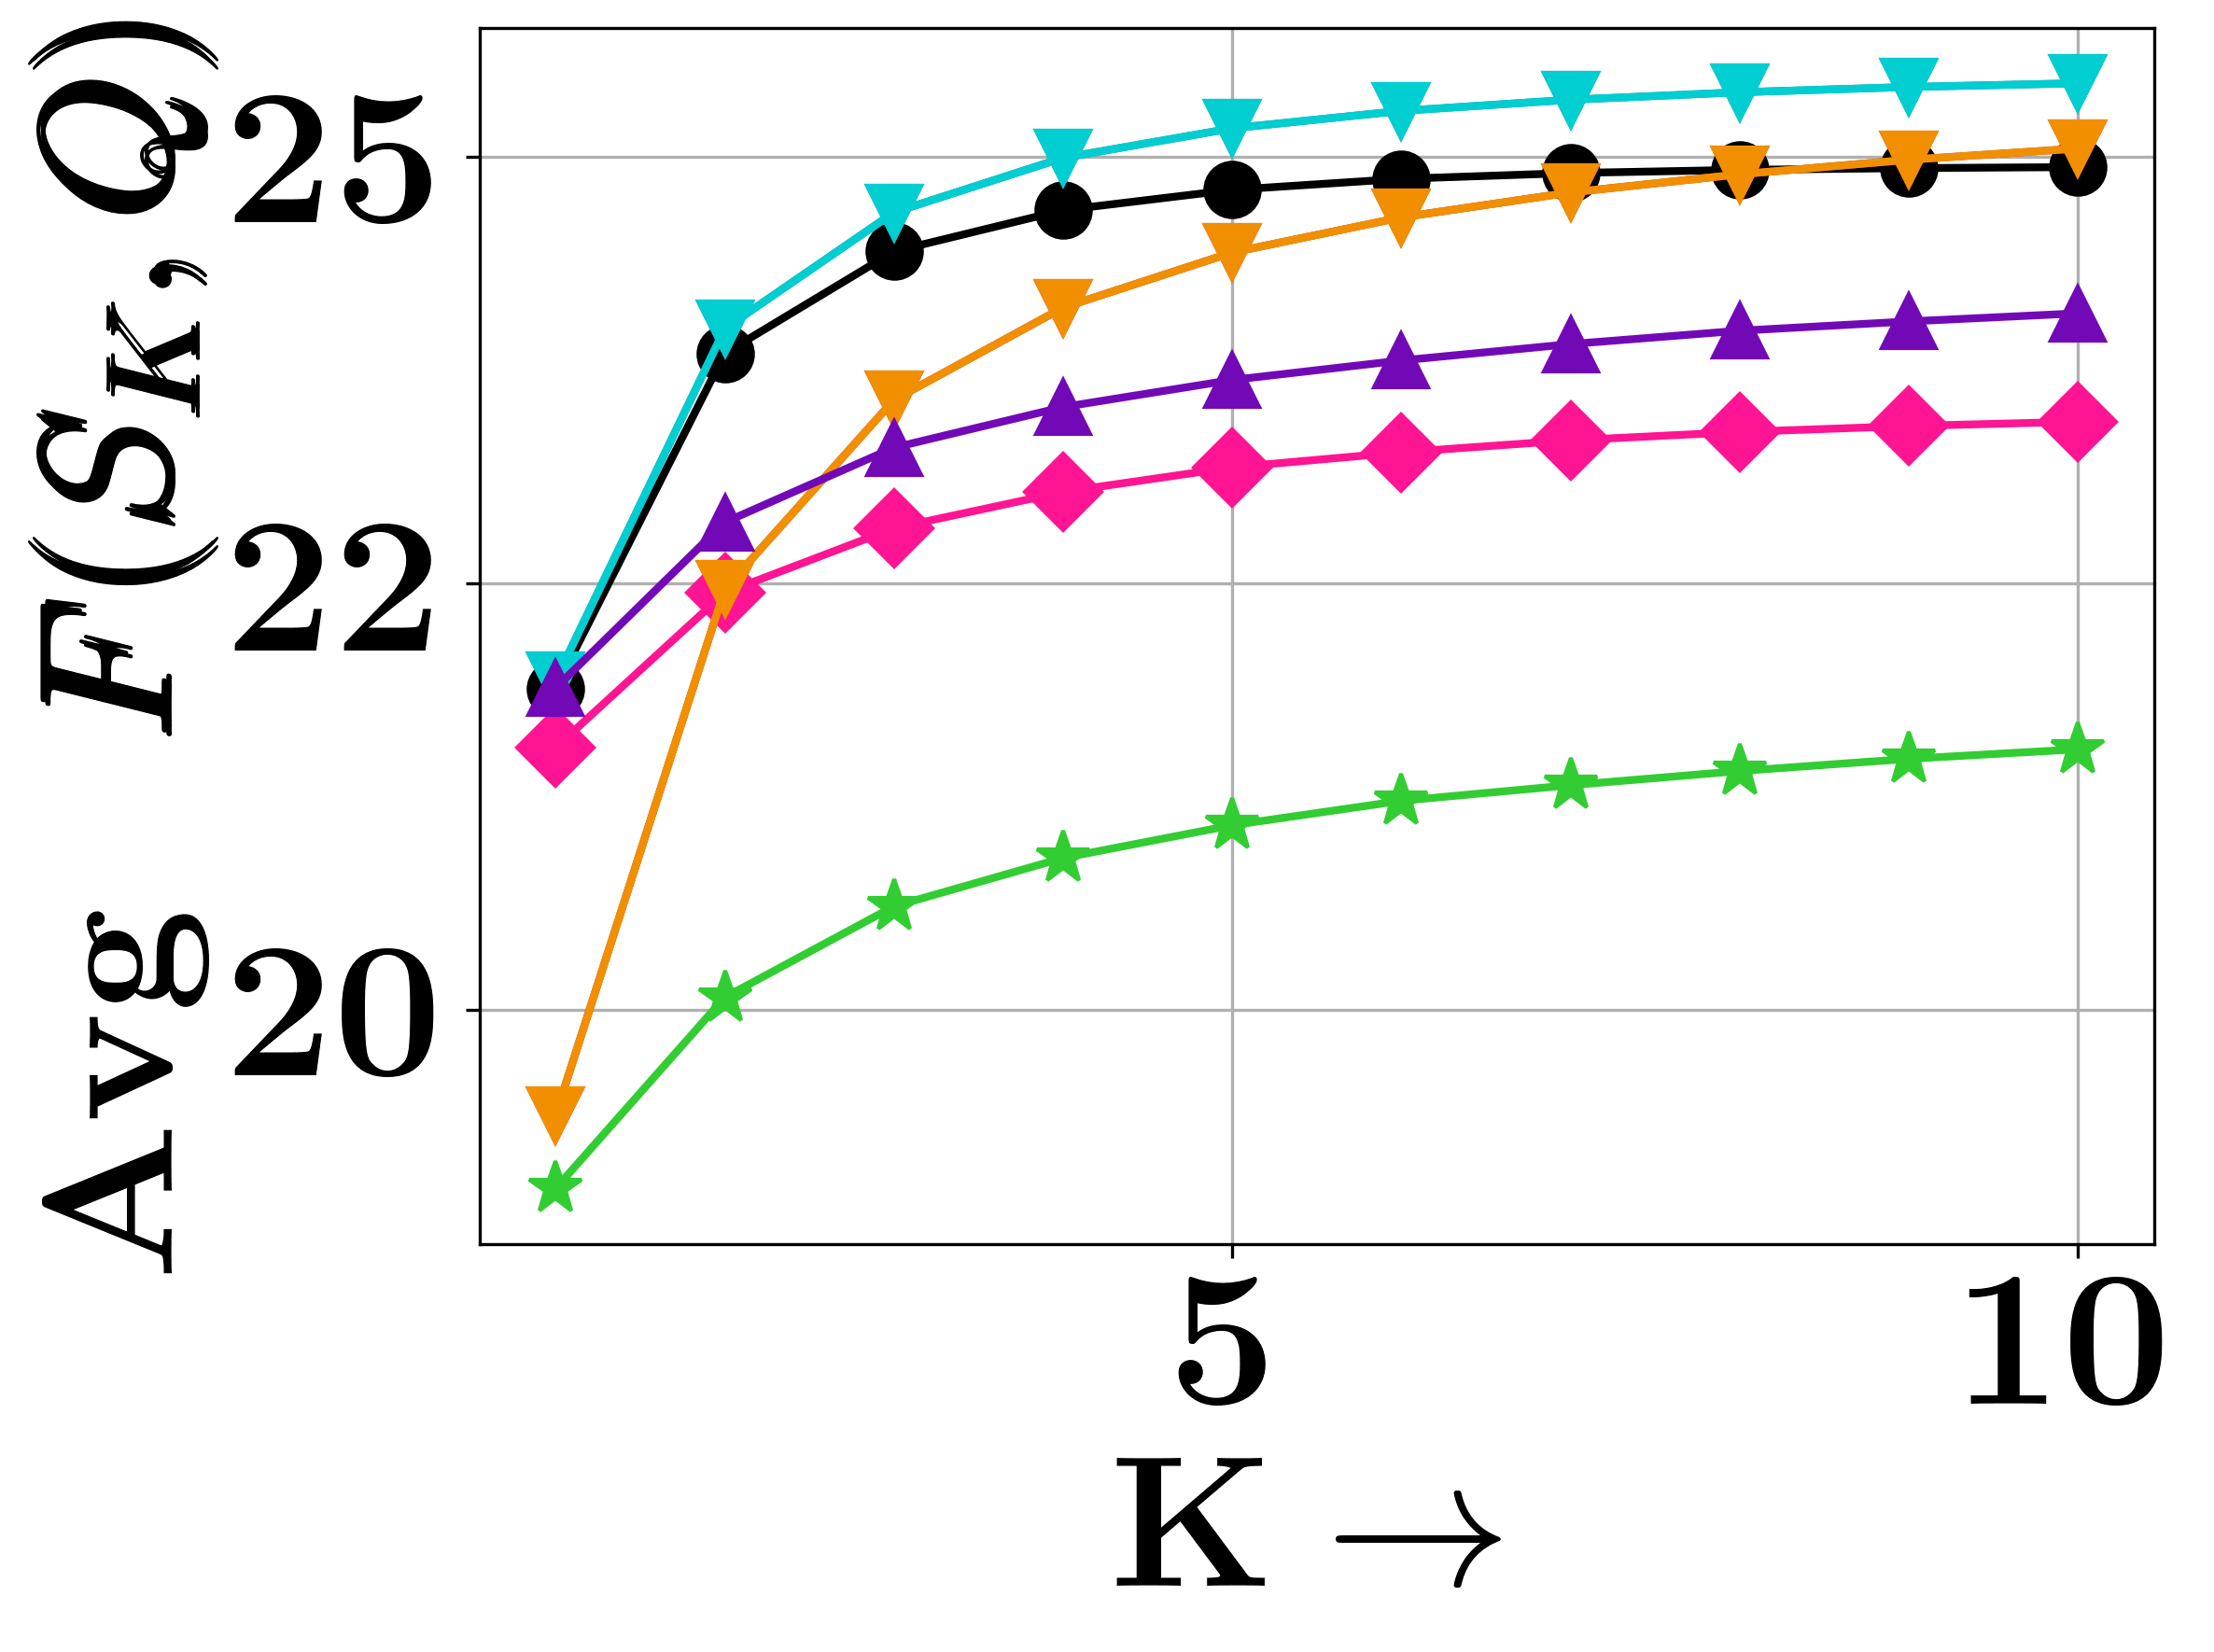

In [20]:
plot_paper("science", dms, y_label=True, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [22.387441635131836, 24.49960708618164, 25.165668487548828, 25.445789337158203, 25.575258255004883, 25.6447811126709, 25.68406105041504, 25.705015182495117, 25.717374801635742, 25.72515869140625]
Method: submodlib ltl 0.5, Score: [18.699180603027344, 22.263202667236328, 23.7067928314209, 24.431394577026367, 24.84684944152832, 25.12456703186035, 25.331016540527344, 25.479890823364258, 25.594215393066406, 25.680530548095703]
Method: exact greedy, Score: [22.417198181152344, 24.61825180053711, 25.378461837768555, 25.72907257080078, 25.91632652282715, 26.029508590698242, 26.100866317749023, 26.148847579956055, 26.181747436523438, 26.204679489135742]
Method: MUVERA iid, Score: [19.610034942626953, 20.79461097717285, 21.361928939819336, 21.683725357055664, 21.872724533081055, 22.006031036376953, 22.096099853515625, 22.15630531311035, 22.19383430480957, 22.217748641967773]
Method: submodlib lazy, Score: [22.417200088500977, 24.61825180053711, 25.378461837768

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

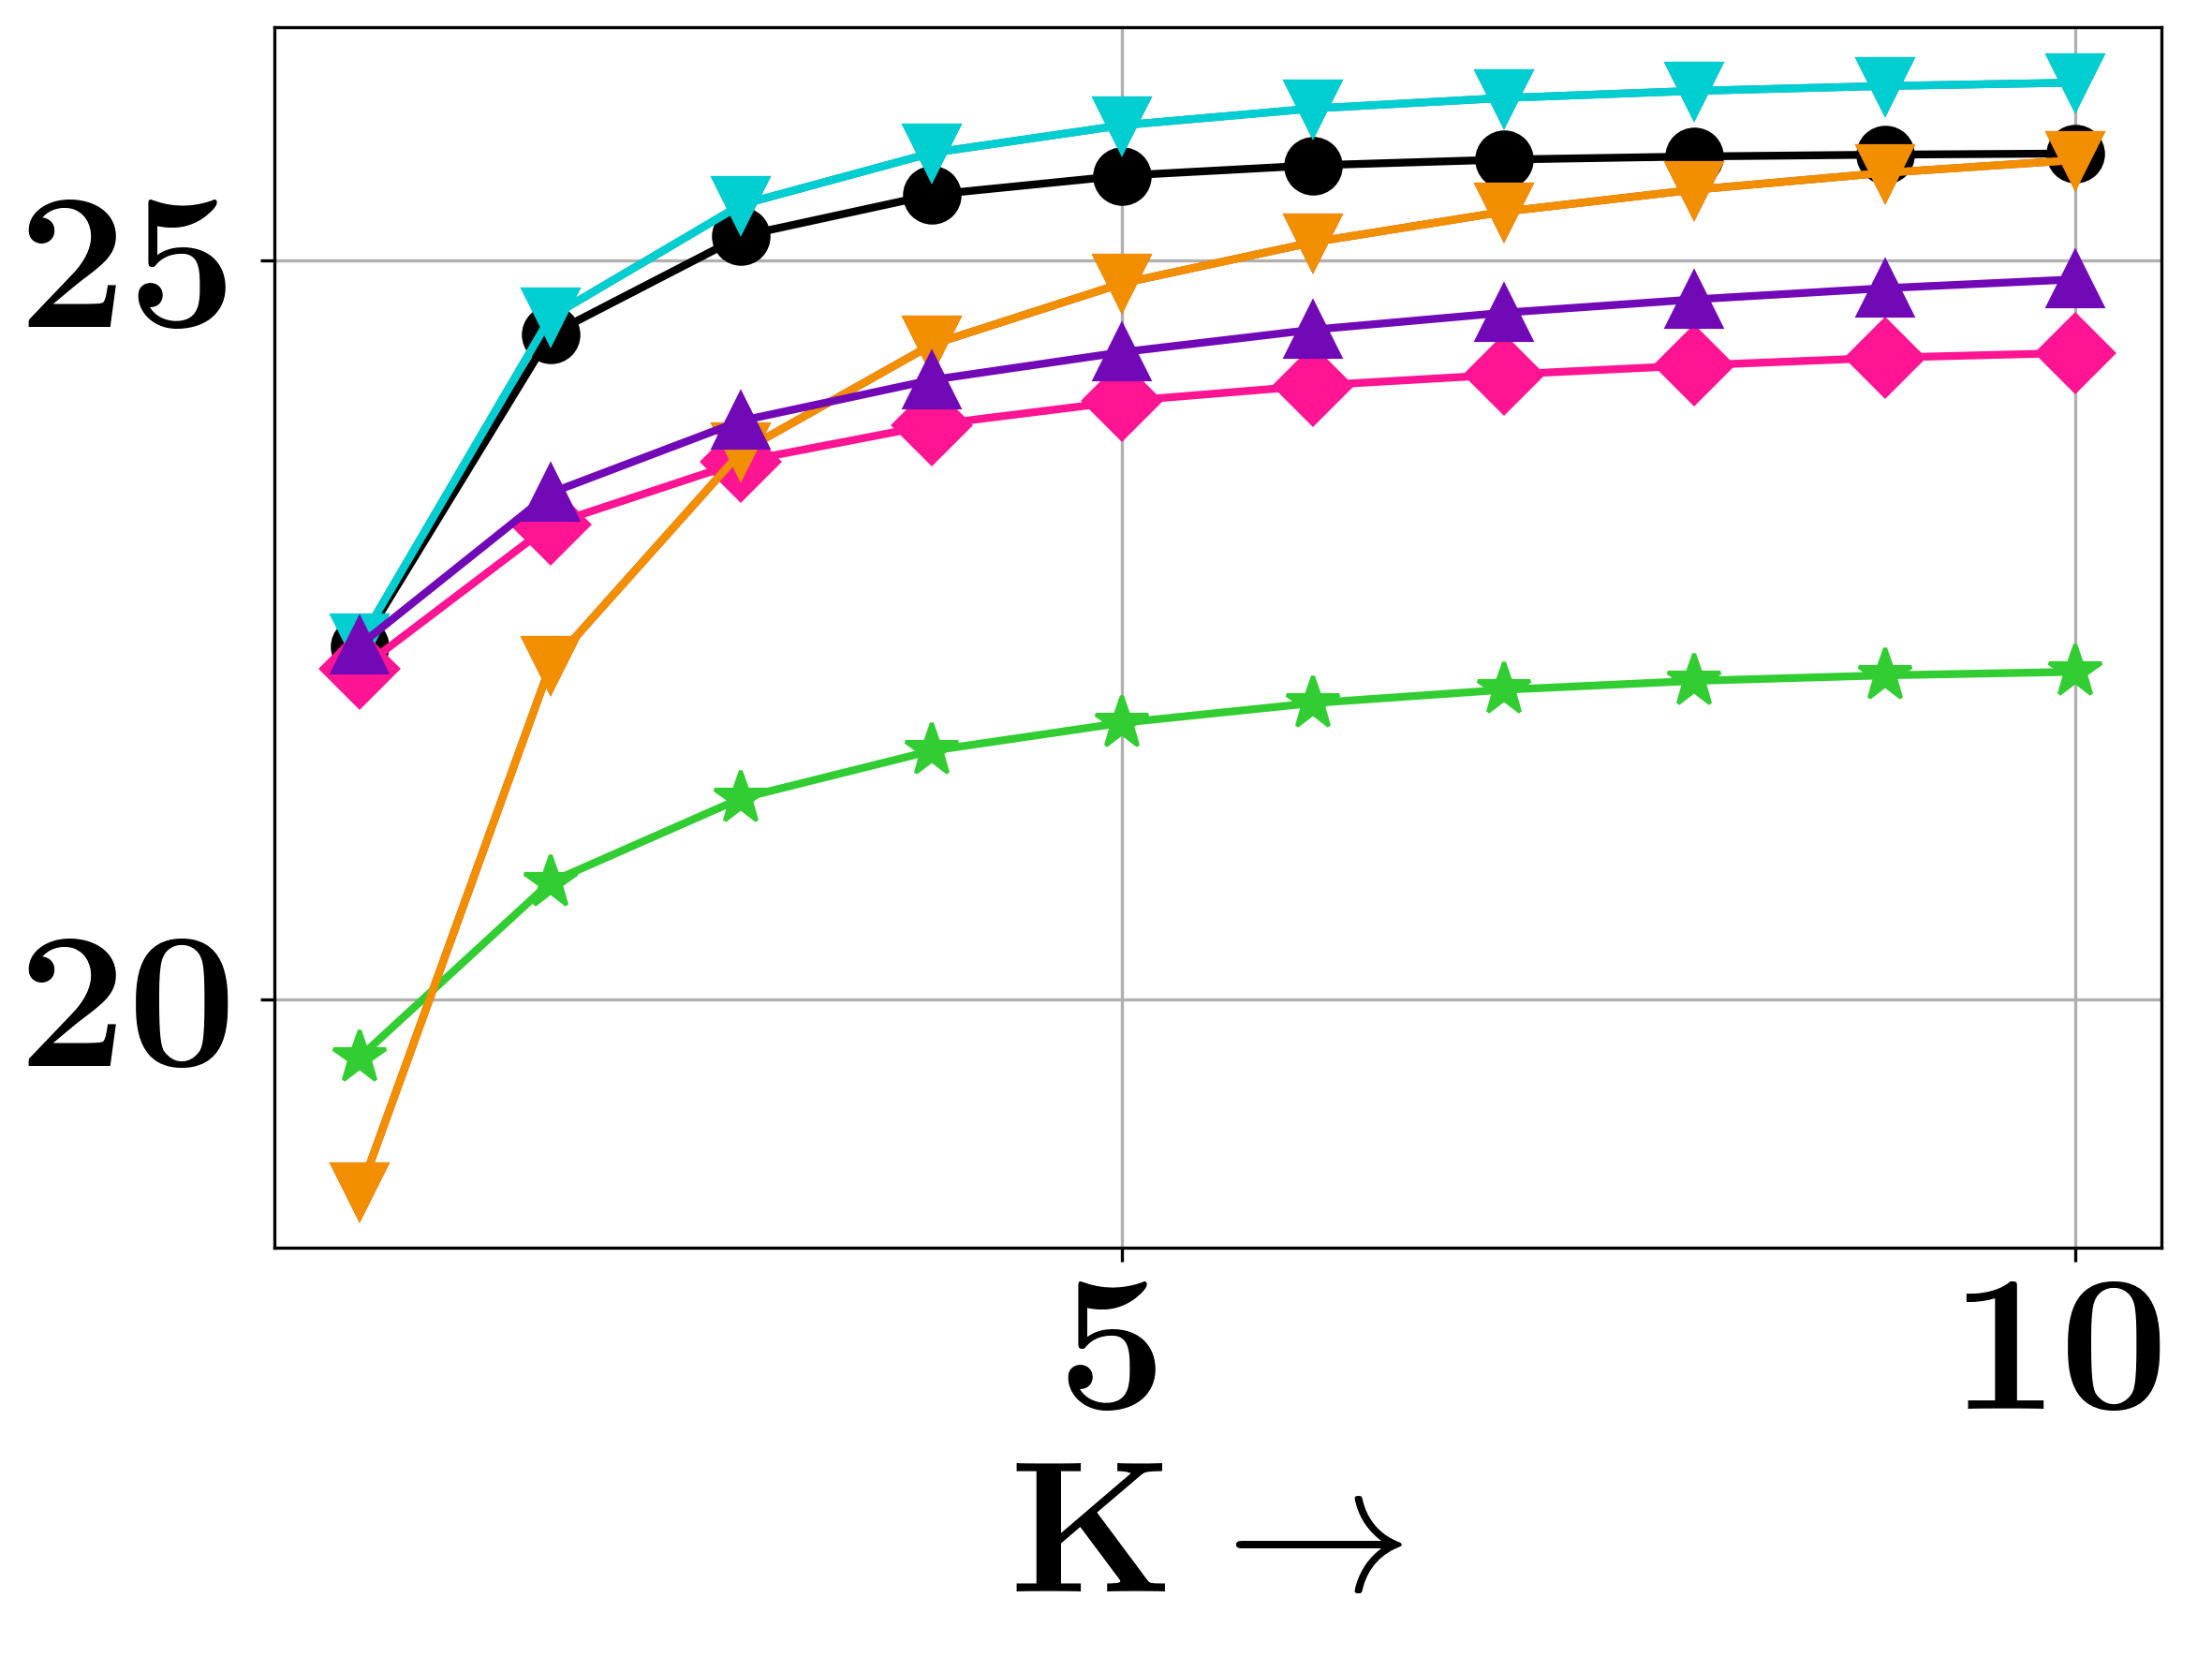

In [21]:
plot_paper("writing", dms, y_label=False, k_cutoff=10)

Method: ColBERT bypass - 1, Score: [22.84028434753418, 24.938852310180664, 25.58439826965332, 25.857093811035156, 25.98836326599121, 26.05767059326172, 26.09765625, 26.120773315429688, 26.13334083557129, 26.14117431640625]
Method: submodlib ltl 0.5, Score: [19.825626373291016, 23.28840446472168, 24.53520393371582, 25.120956420898438, 25.47295570373535, 25.706335067749023, 25.868274688720703, 25.98969841003418, 26.083574295043945, 26.15794563293457]
Method: exact greedy, Score: [22.860383987426758, 25.021953582763672, 25.74329948425293, 26.089941024780273, 26.284040451049805, 26.400897979736328, 26.476882934570312, 26.527620315551758, 26.56273078918457, 26.587892532348633]
Method: MUVERA iid, Score: [20.12441062927246, 21.473461151123047, 22.09771156311035, 22.47374725341797, 22.720308303833008, 22.87164878845215, 22.997314453125, 23.08201026916504, 23.14640235900879, 23.19383430480957]
Method: submodlib lazy, Score: [22.860382080078125, 25.021953582763672, 25.743295669555664, 26.089937

/tmp/ipykernel_1364709/1301737806.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_1364709/1301737806.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

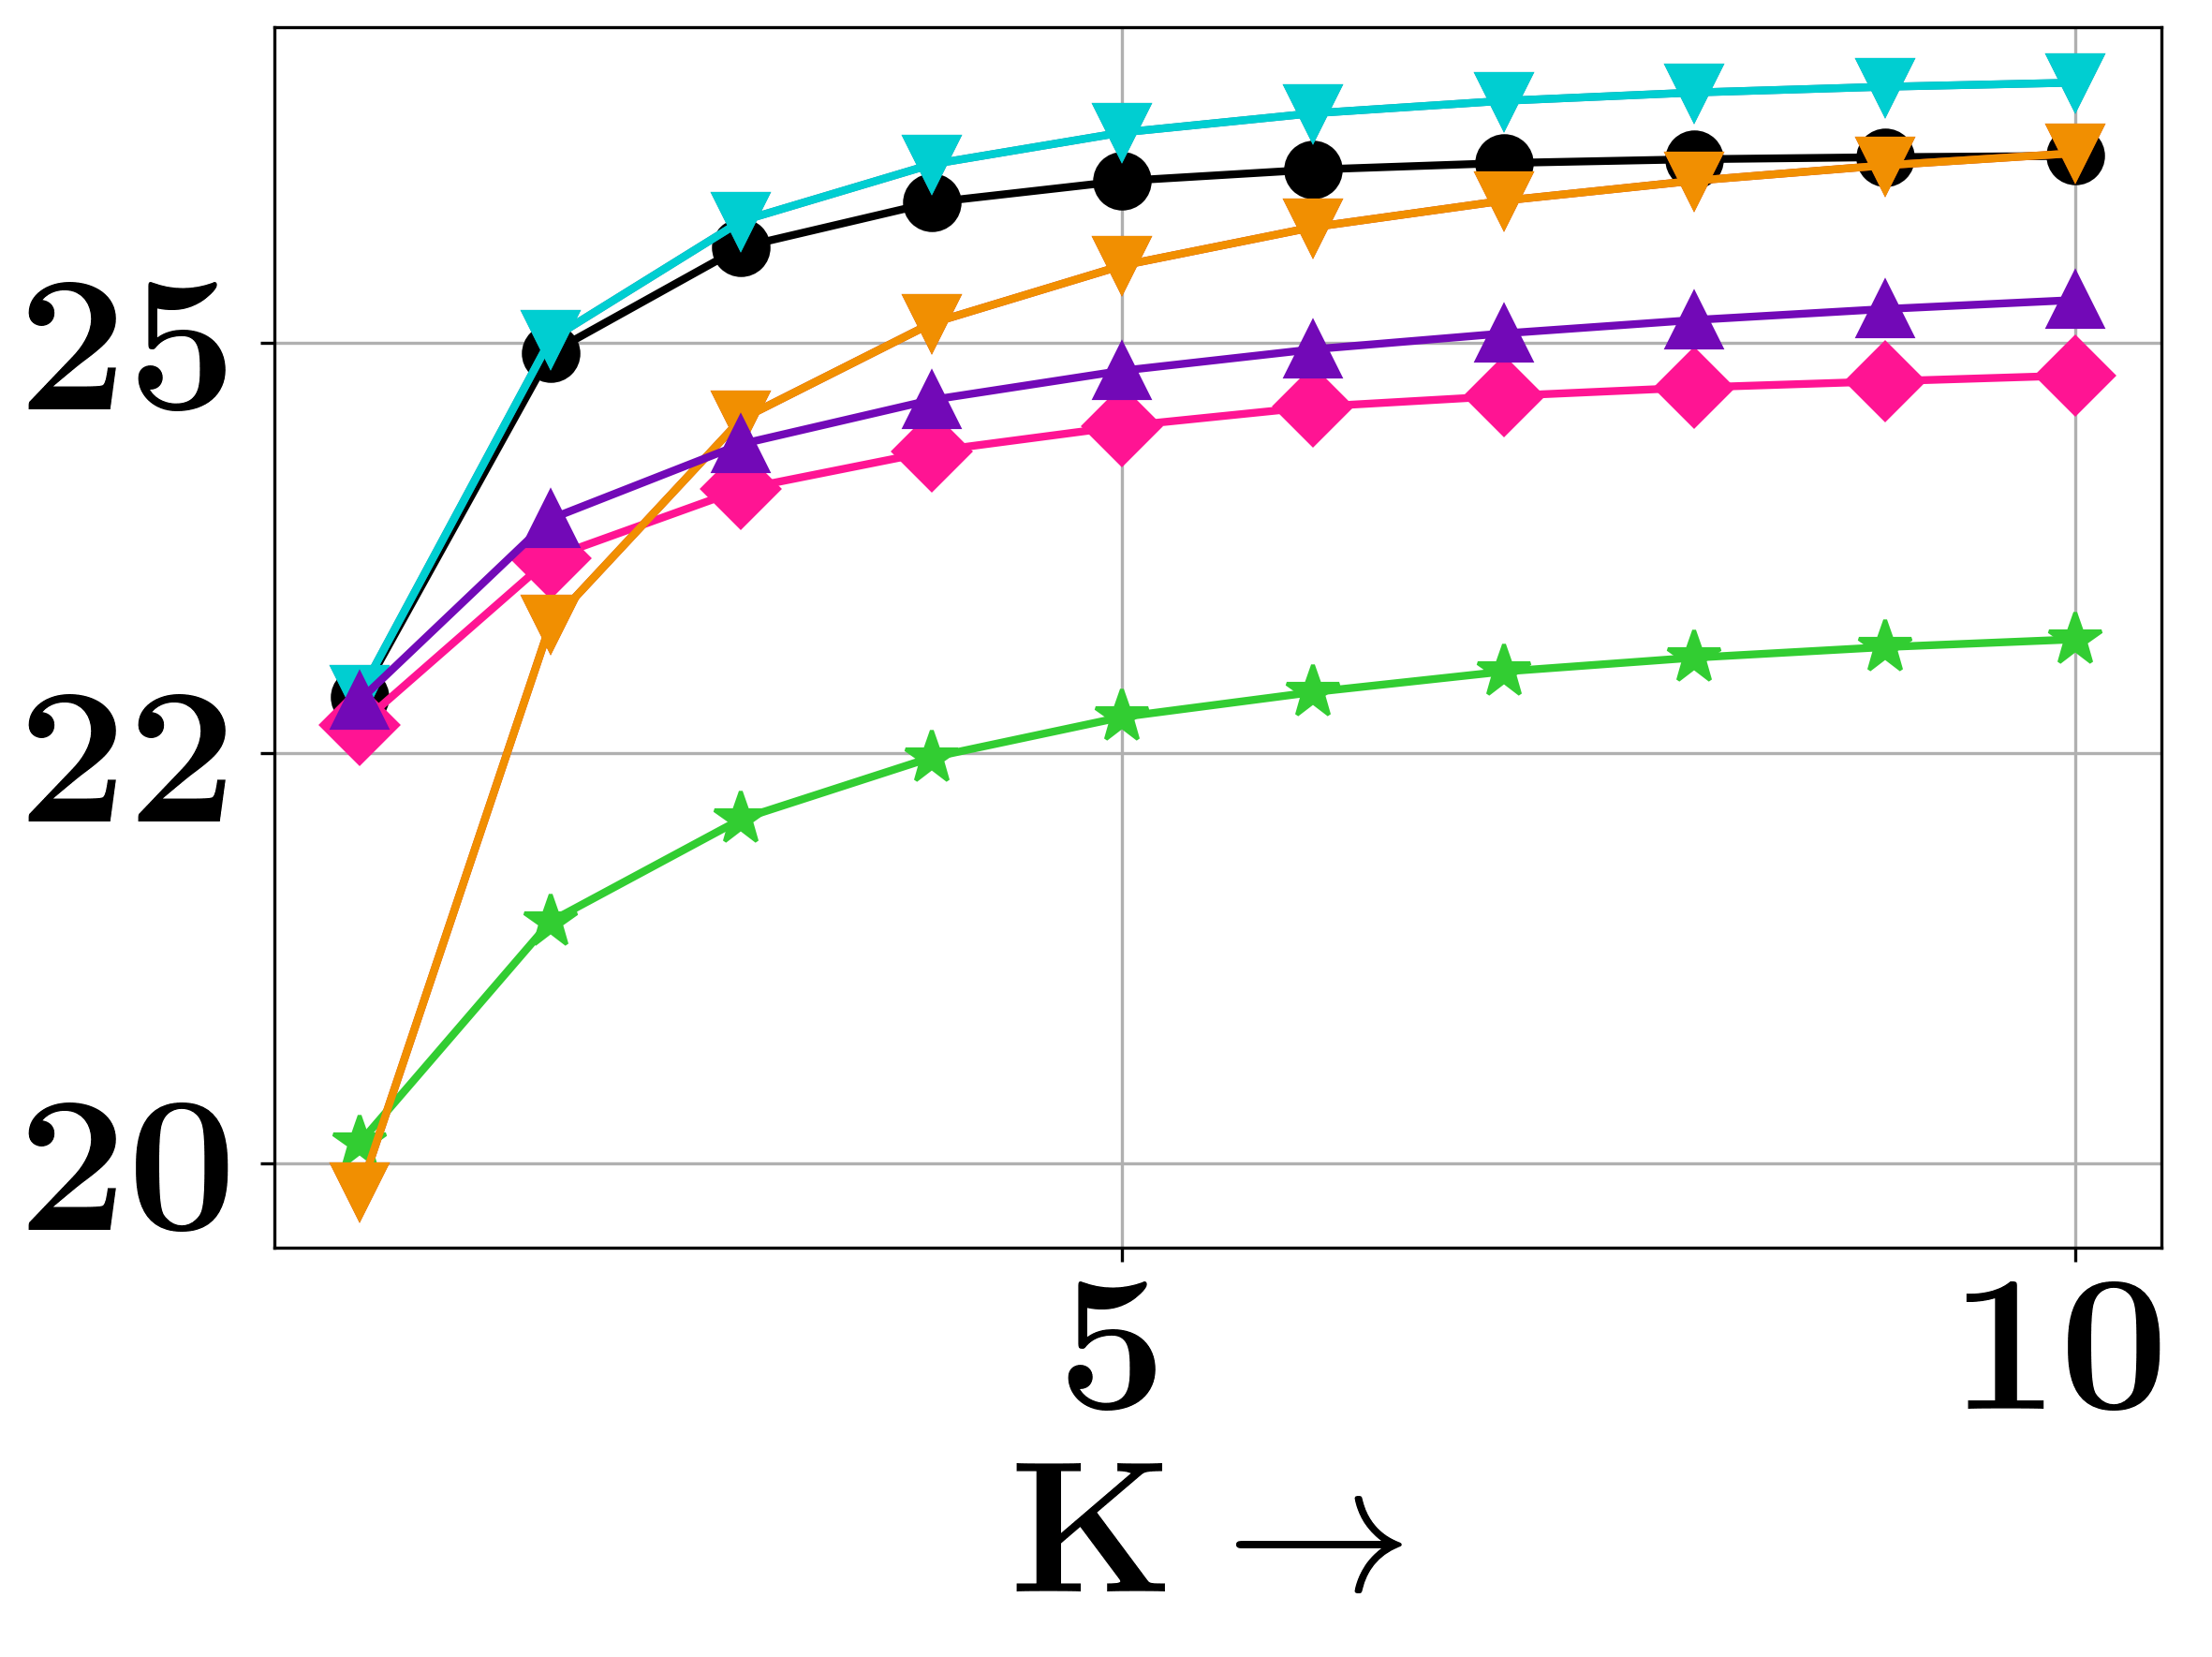

In [22]:
plot_paper("technology", dms, y_label=False, k_cutoff=10)